# Bunker 🛡️
### The minimum-volatility ETF — a calmer ride, but a better one?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Delivers the low-vol Sharpe edge?: Not supported](https://img.shields.io/badge/Delivers_the_low--vol_Sharpe_edge%3F-Not_supported-8b949e?style=flat-square)

The low-volatility anomaly says boring, stable stocks earn *better risk-adjusted* returns. The product that sells it is the min-vol ETF. It does deliver the calm — 20% less volatility, a shallower drawdown — but over 2011–2026 it didn't beat the market on Sharpe. A good bunker, not a free lunch.

> 📓 **Plain-language layer.** The numbers and the regime caveat are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (bunker/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from bunker import data, strategy as st
ret = data.fetch_pairs()                       # cache-first
al = ret[["USMV","SPY"]].dropna()              # common window (USMV starts 2011)
sp = st.spread(ret, "USMV", "SPY")


## The answer first 🎯

| The promise | The data (2011–2026) |
|---|---|
| "Lower risk" | True: vol **11.4% vs 14.3%**, drawdown **−20% vs −24%**. |
| "Better risk-adjusted returns" | No: Sharpe **0.99 vs 1.05**. |
| "A free Sharpe edge" | It trailed on return (−3.5%/yr spread). |

## 1 · The claim

The low-vol anomaly (Baker-Bradley-Wurgler 2011; the desk's [Study 18 Dull-Roar](../../18-dull-roar/)): calm stocks earn higher *risk-adjusted* returns. USMV is the min-vol ETF that packages it for investors.

## 2 · So what?

Min-vol products gather tens of billions on the promise of equity returns with bond-like calm. If they only cut risk *proportionally* — same Sharpe — that's a fine defensive tool but not the anomaly's free lunch. Worth checking which it is.

## 3 · How would we even know?

Compare USMV to SPY over USMV's life, leg by leg: does it cut volatility and drawdown (risk), *and* does it beat the market on Sharpe (the anomaly)?

In [2]:
import pandas as pd
display(pd.DataFrame({'USMV (min-vol)':st.leg_summary(al,'USMV'),'SPY (market)':st.leg_summary(al,'SPY')}).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))
print('vol reduction USMV/SPY =', round(st.vol_reduction(al,'USMV','SPY'),2))

,cagr,sharpe,vol_ann,max_drawdown
USMV (min-vol),0.114,1.003,0.114,-0.196
SPY (market),0.148,1.046,0.143,-0.240


vol reduction USMV/SPY = 0.8


## 4 · The teardown

USMV is genuinely calmer — lower vol, shallower drawdown. But the lower risk came with lower return, so the Sharpe landed just below the market's.

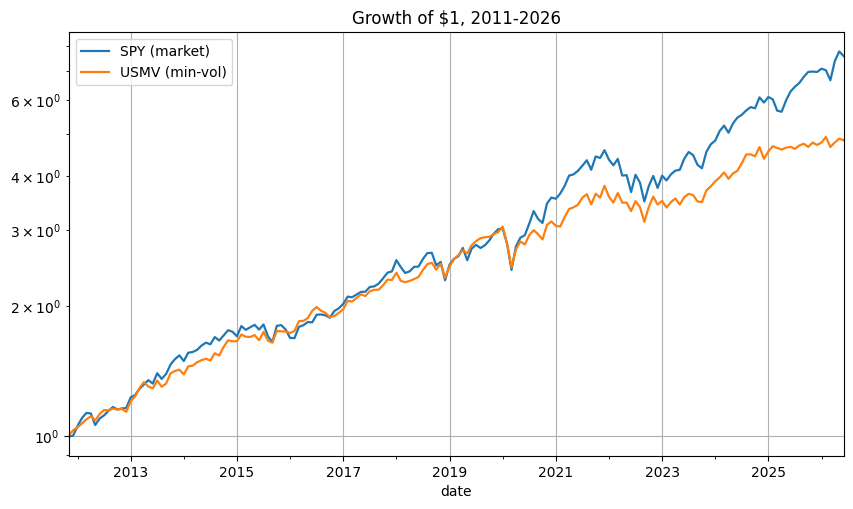

spread USMV-SPY: -3.46%/yr, Sharpe -0.48


In [3]:
eqU=(1+al['USMV']).cumprod(); eqS=(1+al['SPY']).cumprod()
ax=eqS.plot(label='SPY (market)',lw=1.6); eqU.plot(ax=ax,label='USMV (min-vol)',lw=1.6)
ax.set_yscale('log'); ax.set_title('Growth of $1, 2011-2026'); ax.legend(); plt.show()
s=st.spread_stats(sp); print(f"spread USMV-SPY: {s['mean_ann']:+.2%}/yr, Sharpe {s['sharpe']:.2f}")

**Read it plainly.** A smoother but lower line. Min-vol bought you calm, not extra risk-adjusted return — at least in this bull-heavy stretch. Its edge lives in the bear markets this sample mostly lacked.

## 5 · The verdict

**Signal: Weak** — cuts risk, not a Sharpe edge. **Tradability: Fragile** — a defensive tool, trailed the market. **Delivers the low-vol Sharpe edge?: Not supported** here.

## 6 · Could you actually trade it?

Yes — and as a *defensive* holding it does its job (less volatility, smaller drawdowns). Just don't expect it to beat the market; the anomaly's risk-adjusted edge shows up over full cycles and in bear markets, not a 2011–2026 bull run.

## 7 · Going further 🚪

Compare with the academic long-short in [Study 18 Dull-Roar](../../18-dull-roar/), and the high-risk-won mirror in [43 Free-Lunch](../../43-free-lunch/) / [53 Jackpot](../../53-jackpot/).